# SETUP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random 
from warnings import filterwarnings
import re
from wordcloud import WordCloud
import string
from scipy.stats import skew, kurtosis
from collections import Counter
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

import pickle

filterwarnings('ignore')
plt.style.use('ggplot')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

In [119]:
PATH = '../data/DATA RUMAH.xlsx'
data = pd.read_excel(PATH, index_col=0)

# DATASET

In [120]:
def summary(df):
    print(f"Shape: {df.shape}\n")

    print("Features:")
    for i, col in enumerate(df.columns):
        print(f"{i+1}. {col}")

    print("\nSummary:")
    summ = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing Values (%)': df.isnull().mean() * 100,
        'Unique Values': df.nunique()
    })

    display(summ)

    print("\nSample Data:")
    display(df.head())
summary(data)

Shape: (1010, 7)

Features:
1. NAMA RUMAH
2. HARGA
3. LB
4. LT
5. KT
6. KM
7. GRS

Summary:


,Data Type,Missing Values,Missing Values (%),Unique Values
NAMA RUMAH,object,0,0.0,949
HARGA,int64,0,0.0,209
LB,int64,0,0.0,156
LT,int64,0,0.0,265
KT,int64,0,0.0,9
KM,int64,0,0.0,10
GRS,int64,0,0.0,11



Sample Data:


,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
NO,,,,,,,
1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3


In [121]:
def preprocess_columns(df):
    df = df.copy()

    rename_cols = {
        'NAMA RUMAH': 'nama_rumah',
        'HARGA': 'harga',
        'LB': 'luas_bangunan',
        'LT': 'luas_tanah',
        'KT': 'kamar_tidur',
        'KM': 'kamar_mandi',
        'GRS': 'garasi',
    }

    df = df.rename(columns=rename_cols)

    def cleaning_nama_rumah(name):
        name = name.lower()
        STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
        def remove_stopwords(text):
            tokens = word_tokenize(text)
            filtered_tokens = [word for word in tokens if word not in STOPWORDS]
            return ' '.join(filtered_tokens)
        name = remove_stopwords(name)
        name = re.sub(r'[^a-z0-9\s]', '', name)
        name = re.sub(rf'[{string.punctuation}]', ' ', name)
        name = re.sub(r'\s+', ' ', name).strip()
        return name
    df['nama_rumah'] = df['nama_rumah'].apply(cleaning_nama_rumah)
    return df

data = preprocess_columns(data)
summary(data)



Shape: (1010, 7)

Features:
1. nama_rumah
2. harga
3. luas_bangunan
4. luas_tanah
5. kamar_tidur
6. kamar_mandi
7. garasi

Summary:


,Data Type,Missing Values,Missing Values (%),Unique Values
nama_rumah,object,0,0.0,890
harga,int64,0,0.0,209
luas_bangunan,int64,0,0.0,156
luas_tanah,int64,0,0.0,265
kamar_tidur,int64,0,0.0,9
kamar_mandi,int64,0,0.0,10
garasi,int64,0,0.0,11



Sample Data:


,nama_rumah,harga,luas_bangunan,luas_tanah,kamar_tidur,kamar_mandi,garasi
NO,,,,,,,
1,rumah murah hook tebet timur tebet jakarta sel...,3800000000,220,220,3,3,0
2,rumah modern tebet stasiun tebet jakarta selatan,4600000000,180,137,4,3,2
3,rumah mewah 2 lantai 3 menit tebet tebet jakar...,3000000000,267,250,4,4,4
4,rumah tebet tebet jakarta selatan,430000000,40,25,2,2,0
5,rumah bagus tebet komp gudang peluru lt 350m t...,9000000000,400,355,6,5,3


In [122]:
numeric = data.select_dtypes(include=np.number).columns.tolist()
text = ['nama_rumah']

In [18]:
print("Statistical Summary for Numeric Features:")
display(data[numeric].describe().T)

Statistical Summary for Numeric Features:


,count,mean,std,min,25%,50%,75%,max
harga,1010.0,7.628987e+09,7.340946e+09,430000000.0,3.262500e+09,5.000000e+09,9.000000e+09,6.500000e+10
luas_bangunan,1010.0,2.765396e+02,1.778646e+02,40.0,1.500000e+02,2.165000e+02,3.500000e+02,1.126000e+03
luas_tanah,1010.0,2.374327e+02,1.799576e+02,25.0,1.300000e+02,1.650000e+02,2.900000e+02,1.400000e+03
kamar_tidur,1010.0,4.668317e+00,1.572776e+00,2.0,4.000000e+00,4.000000e+00,5.000000e+00,1.000000e+01
kamar_mandi,1010.0,3.607921e+00,1.420066e+00,1.0,3.000000e+00,3.000000e+00,4.000000e+00,1.000000e+01
garasi,1010.0,1.920792e+00,1.510998e+00,0.0,1.000000e+00,2.000000e+00,2.000000e+00,1.000000e+01


In [123]:
print(f"Total Duplicate Rows: {data.duplicated().sum()}")
data.drop_duplicates(inplace=True)
print(f"Total Rows after removing duplicates: {data.shape[0]}")

Total Duplicate Rows: 2
Total Rows after removing duplicates: 1008


# EDA

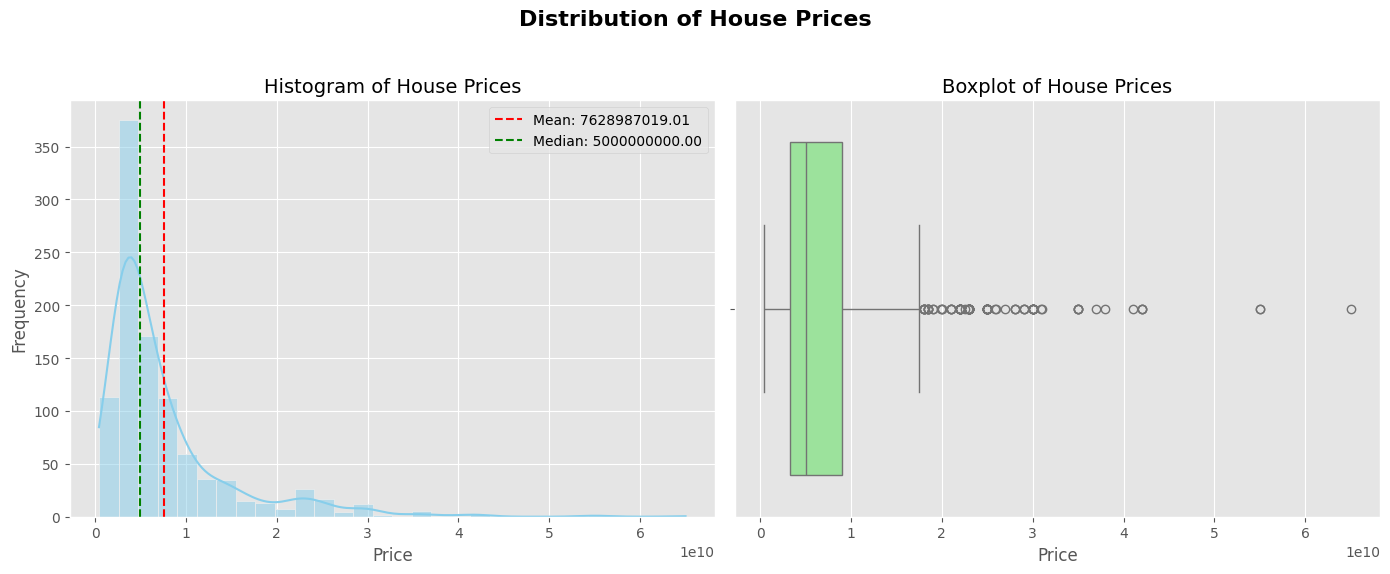

In [108]:
def plot_label(df):
    plt.figure(figsize=(14, 6))
    plt.suptitle('Distribution of House Prices', fontsize=16,fontweight='bold')
    plt.subplot(1, 2, 1)
    sns.histplot(df['harga'], bins=30, kde=True, color='skyblue')
    plt.axvline(df['harga'].mean(), color='red', linestyle='--', label=f'Mean: {df["harga"].mean():.2f}')
    plt.axvline(df['harga'].median(), color='green', linestyle='--', label=f'Median: {df["harga"].median():.2f}')
    plt.legend()
    plt.title('Histogram of House Prices', fontsize=14)
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df['harga'], color='lightgreen')
    plt.title('Boxplot of House Prices', fontsize=14)
    plt.xlabel('Price')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
plot_label(data)

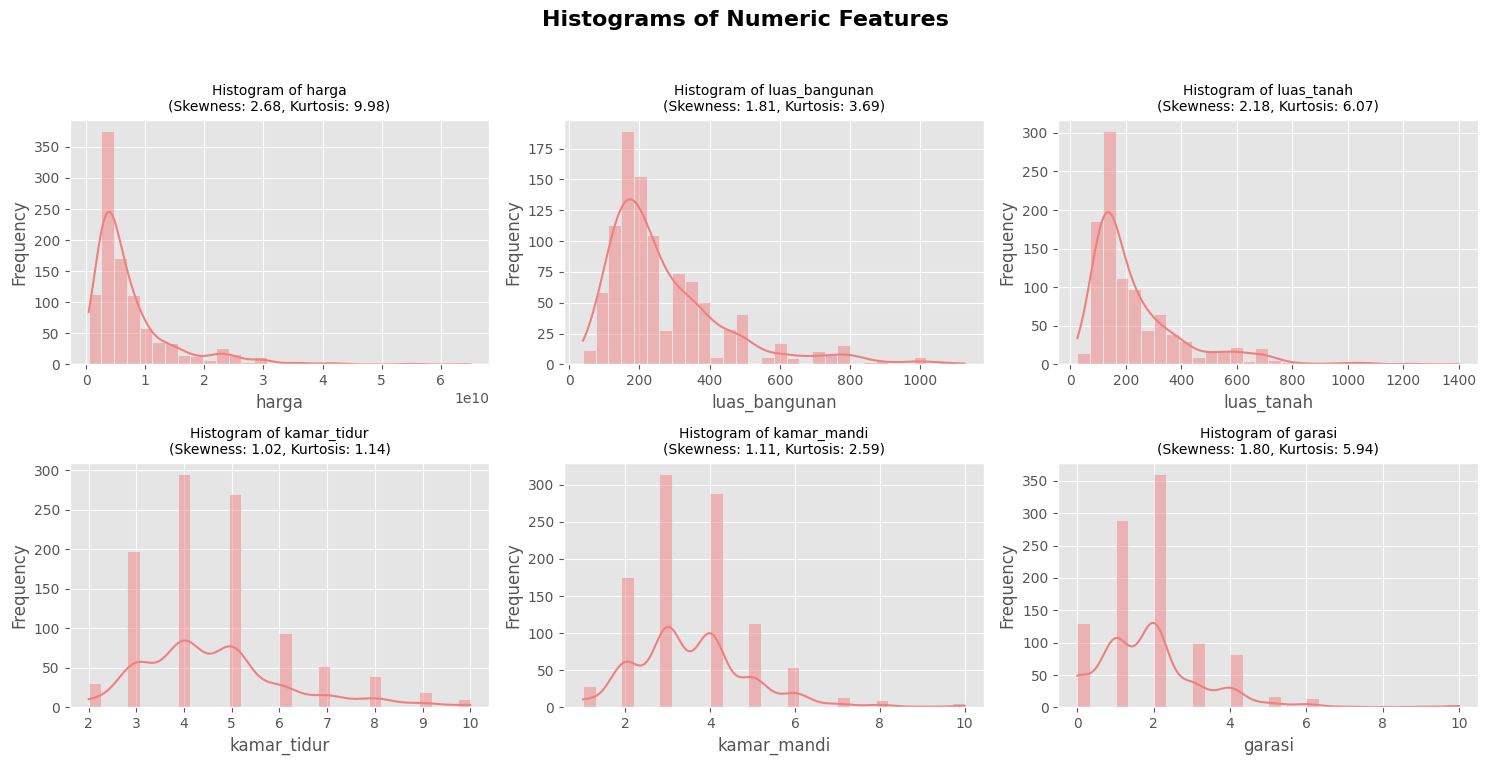

In [109]:
def plot_hist_numeric(df, numeric):
    length = len(numeric)
    cols = 3
    rows = length // cols + int(length % cols > 0)
    plt.figure(figsize=(cols * 5, rows * 4))
    plt.suptitle('Histograms of Numeric Features', fontsize=16, fontweight='bold')
    for i, col in enumerate(numeric):
        plt.subplot(rows, cols, i + 1)
        sns.histplot(df[col], bins=30, kde=True, color='lightcoral')
        plt.title(f'Histogram of {col}\n(Skewness: {skew(df[col]):.2f}, Kurtosis: {kurtosis(df[col]):.2f})', fontsize=10)
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
plot_hist_numeric(data, numeric)
    

Based on histogram, most numeric features are right skewed. We will do `RobustScaler` because it is robust to outliers and skewed data.

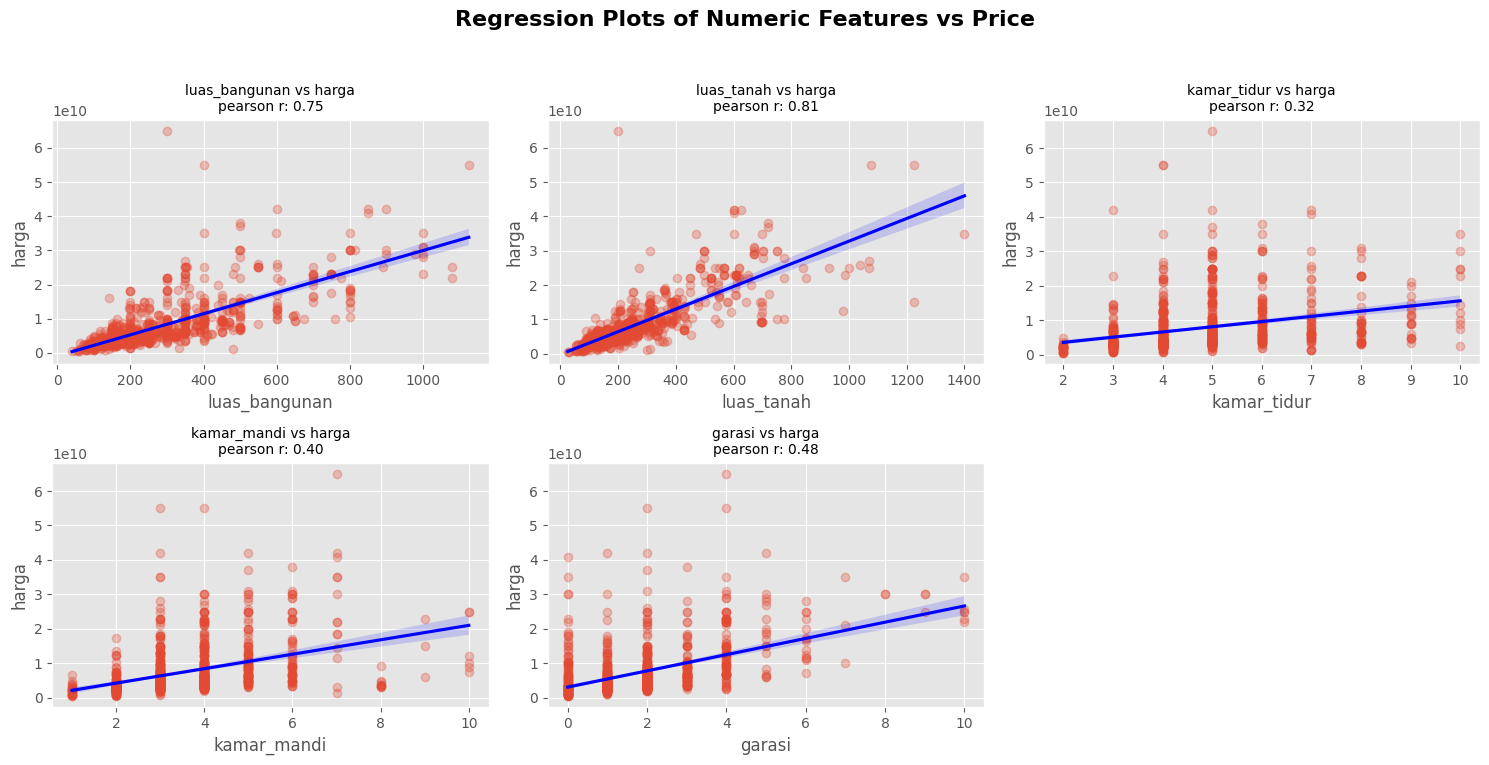

In [124]:
def plot_reg_numeric(df, numeric, label):
    try:
        numeric.remove(label)
    except ValueError:
        pass
    length = len(numeric)
    cols = 3
    rows = length // cols + int(length % cols > 0)
    plt.figure(figsize=(cols * 5, rows * 4))
    plt.suptitle('Regression Plots of Numeric Features vs Price', fontsize=16, fontweight='bold')
    for i, col in enumerate(numeric):
        plt.subplot(rows, cols, i + 1)
        sns.regplot(x=df[col], y=df[label], scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
        plt.title(f'{col} vs {label}\npearson r: {df[col].corr(df[label]):.2f}', fontsize=10)
        plt.xlabel(col)
        plt.ylabel(label)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_reg_numeric(data, numeric, 'harga')

In [125]:
data['harga_binned'] = pd.qcut(data['harga'], q=3, labels=['Low', 'Medium', 'High'])
print(data['harga_binned'].value_counts())

harga_binned
Low       338
Medium    337
High      333
Name: count, dtype: int64


In [43]:
for label in data['harga_binned'].unique():
    l = data[data['harga_binned'] == label]
    print("Minimum Harga for", label, ":", l['harga'].min())
    print("Maximum Harga for", label, ":", l['harga'].max())

Minimum Harga for Medium : 3700000000
Maximum Harga for Medium : 7000000000
Minimum Harga for Low : 430000000
Maximum Harga for Low : 3600000000
Minimum Harga for High : 7100000000
Maximum Harga for High : 65000000000


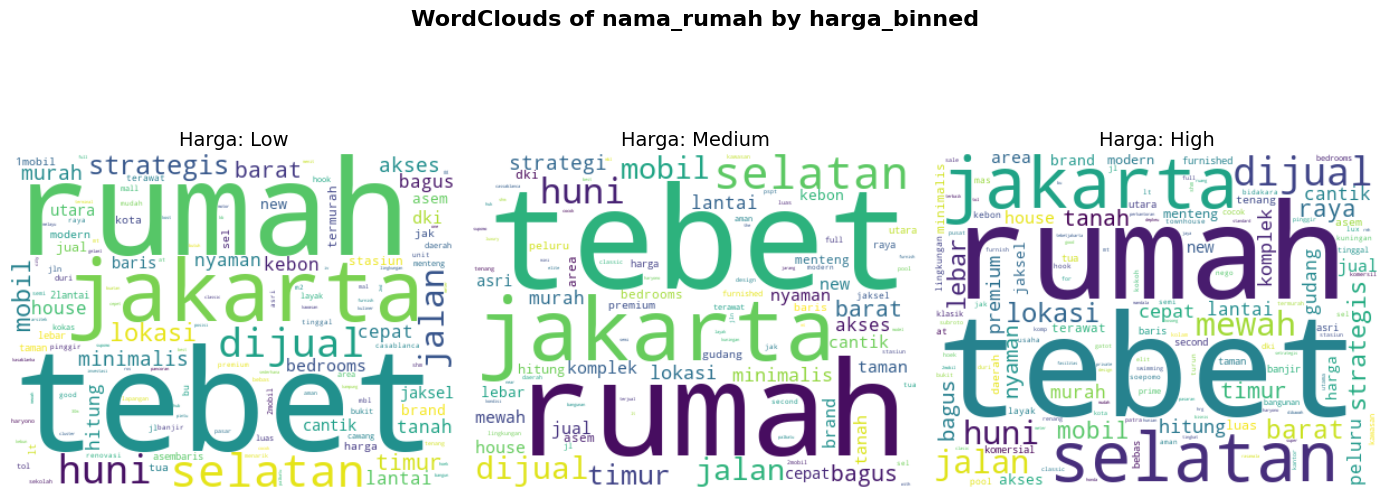

In [ ]:
def plot_wordcloud(df, text_col, label_col):
    plt.figure(figsize=(14, 6))
    plt.suptitle(f'WordClouds of {text_col} by {label_col}', fontsize=16, fontweight='bold')
    labels = df[label_col].unique()
    STOPWORDS = StopWordRemoverFactory().get_stop_words()
    # sort labels to ensure consistent order
    labels = sorted(labels, key=lambda x: ['Low', 'Medium', 'High'].index(x))
    for i, label in enumerate(labels):
        plt.subplot(1, len(labels), i + 1)
        text = ' '.join(df[df[label_col] == label][text_col].values)
        wordcloud = WordCloud(width=400, height=300, background_color='white', stopwords=STOPWORDS, collocations=False).generate(text)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Harga: {label}', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
plot_wordcloud(data, 'nama_rumah', 'harga_binned')

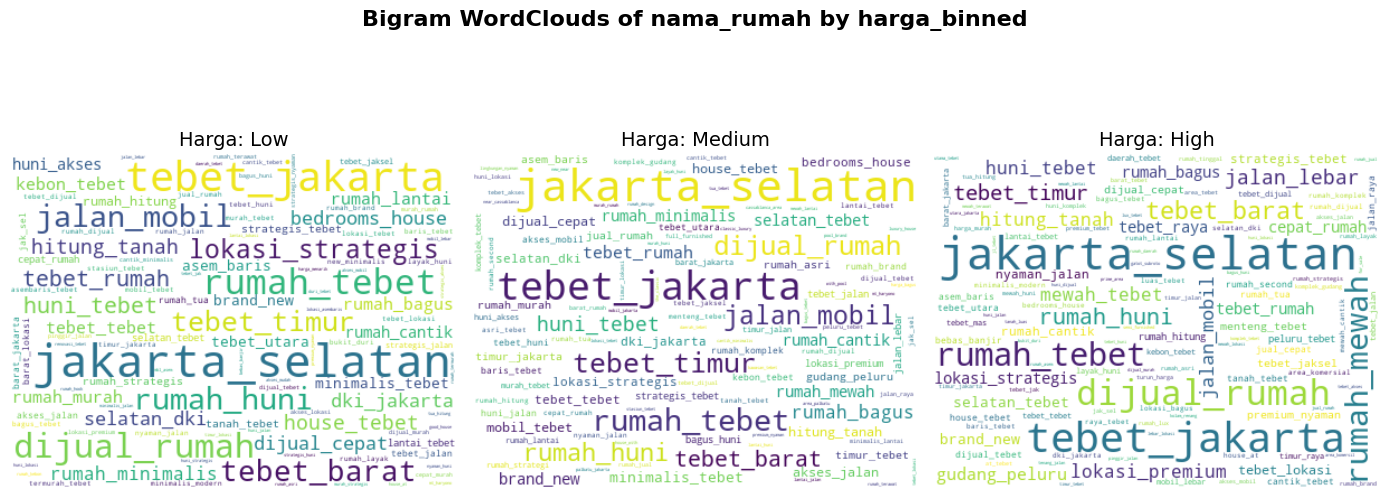

In [ ]:
def plot_wordcloud_bigram(df, text_col, label_col):
    plt.figure(figsize=(14, 6))
    plt.suptitle(f'Bigram WordClouds of {text_col} by {label_col}', 
                 fontsize=16, fontweight='bold')

    labels = df[label_col].unique()
    STOPWORDS = set(StopWordRemoverFactory().get_stop_words())

    # sort labels to ensure consistent order
    labels = sorted(labels, key=lambda x: ['Low', 'Medium', 'High'].index(x))

    for i, label in enumerate(labels):
        plt.subplot(1, len(labels), i + 1)

        texts = df[df[label_col] == label][text_col].values
        bigram_list = []

        for text in texts:
            tokens = word_tokenize(text.lower())
            tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
            bigrams = ngrams(tokens, 2)
            bigram_list.extend(['_'.join(bg) for bg in bigrams])

        bigram_text = ' '.join(bigram_list)

        wordcloud = WordCloud(
            width=400,
            height=300,
            background_color='white',
            collocations=False
        ).generate(bigram_text)

        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Harga: {label}', fontsize=14)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


plot_wordcloud_bigram(data, 'nama_rumah', 'harga_binned')


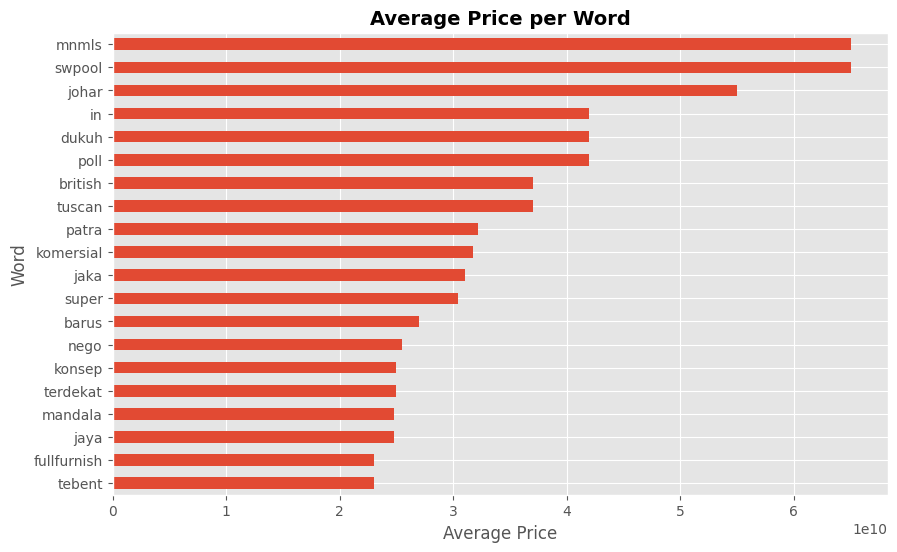

In [ ]:
def plot_word_vs_price(df, text_col, price_col, top_n=20):
    STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
    rows = []

    for _, row in df.iterrows():
        tokens = word_tokenize(row[text_col].lower())
        tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]

        for token in tokens:
            rows.append({
                "word": token,
                "price": row[price_col]
            })

    word_price_df = pd.DataFrame(rows)

    agg = (
        word_price_df
        .groupby("word")["price"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))
    agg.sort_values().plot(kind='barh')
    plt.title("Average Price per Word", fontsize=14, fontweight='bold')
    plt.xlabel("Average Price")
    plt.ylabel("Word")
    plt.show()
plot_word_vs_price(data, 'nama_rumah', 'harga', top_n=20)

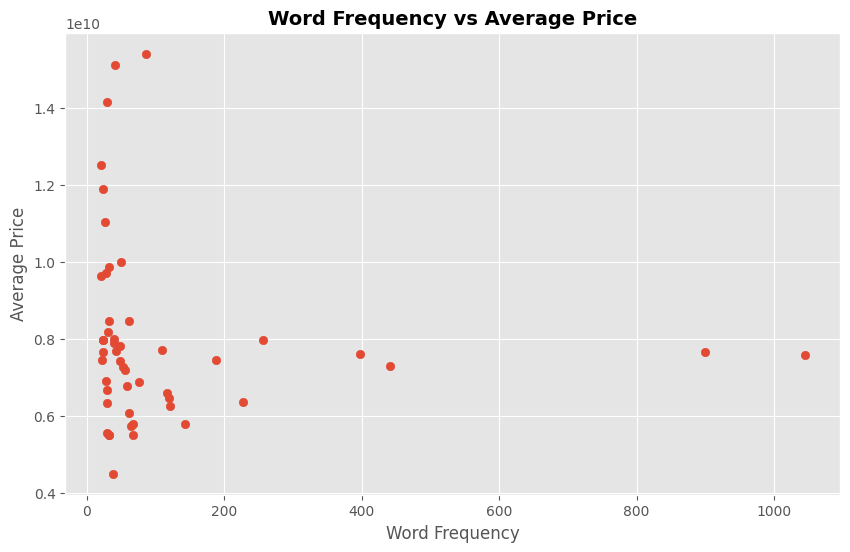

In [53]:
def plot_word_frequency_price(df, text_col, price_col, min_freq=20):
    STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
    rows = []

    for _, row in df.iterrows():
        tokens = word_tokenize(row[text_col].lower())
        tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]

        for token in tokens:
            rows.append({
                "word": token,
                "price": row[price_col]
            })

    word_price_df = pd.DataFrame(rows)

    agg = (
        word_price_df
        .groupby("word")
        .agg(
            avg_price=("price", "mean"),
            freq=("price", "count")
        )
        .query("freq >= @min_freq")
    )

    plt.figure(figsize=(10, 6))
    plt.scatter(agg["freq"], agg["avg_price"])
    plt.xlabel("Word Frequency")
    plt.ylabel("Average Price")
    plt.title("Word Frequency vs Average Price", fontsize=14, fontweight='bold')
    plt.show()

plot_word_frequency_price(data, 'nama_rumah', 'harga', min_freq=20)


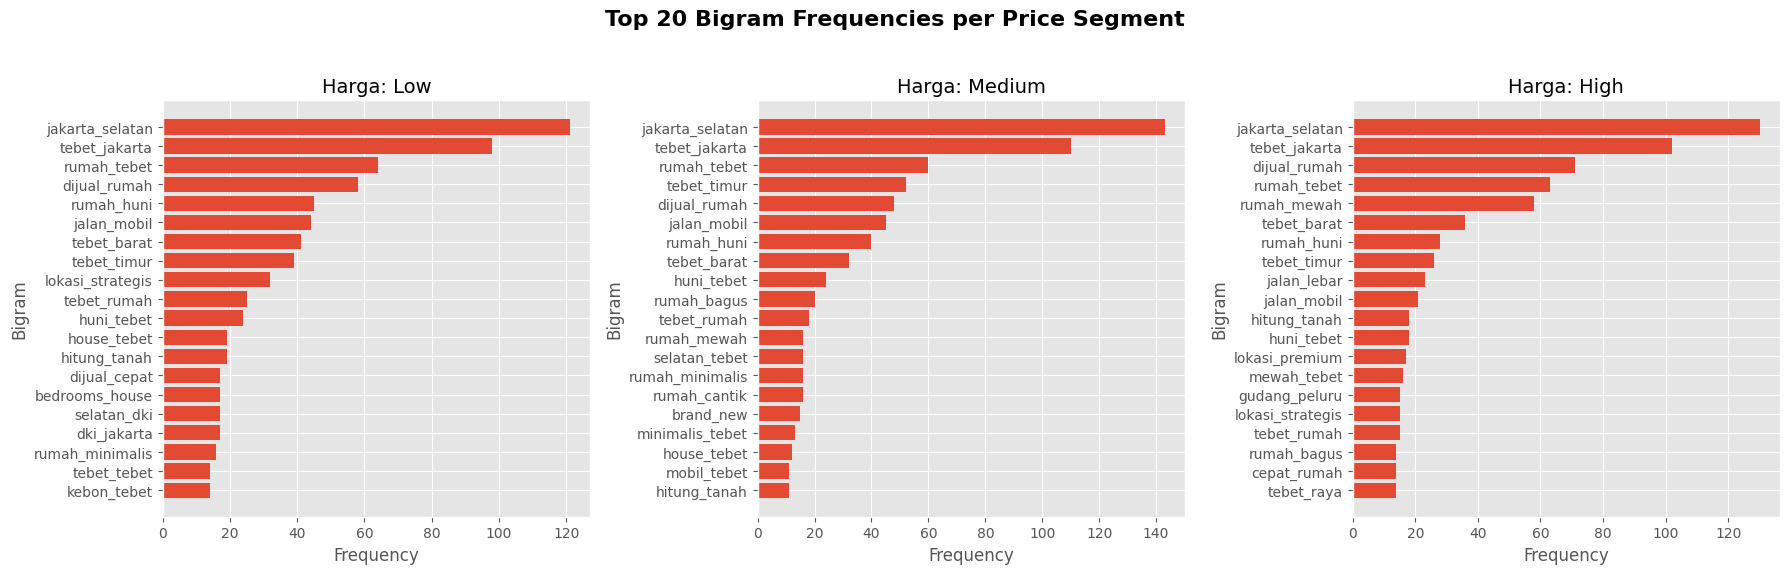

In [ ]:
def plot_top_bigrams_per_price_bin(df, text_col, price_bin_col, top_n=20):
    STOPWORDS = set(StopWordRemoverFactory().get_stop_words())
    price_bins = ["Low", "Medium", "High"]

    plt.figure(figsize=(18, 6))
    plt.suptitle("Top 20 Bigram Frequencies per Price Segment",
                 fontsize=16, fontweight="bold")

    for i, price in enumerate(price_bins):
        subset = df[df[price_bin_col] == price]
        all_bigrams = []

        for text in subset[text_col]:
            tokens = word_tokenize(text.lower())
            tokens = [t for t in tokens if t.isalpha() and t not in STOPWORDS]
            bigrams = ngrams(tokens, 2)
            all_bigrams.extend(['_'.join(bg) for bg in bigrams])

        bigram_freq = Counter(all_bigrams).most_common(top_n)
        bigrams_, freqs = zip(*bigram_freq)

        plt.subplot(1, 3, i + 1)
        plt.barh(bigrams_[::-1], freqs[::-1])
        plt.title(f"Harga: {price}", fontsize=14)
        plt.xlabel("Frequency")
        plt.ylabel("Bigram")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

plot_top_bigrams_per_price_bin(data, 'nama_rumah', 'harga_binned', top_n=20)


# PREPROCESSING

In [ ]:
def add_features(df):
    df = df.copy()
    df['total_kamar'] = df['kamar_tidur'] + df['kamar_mandi']
    df['luas_bangunan_per_kamar_tidur'] = df['luas_bangunan'] / df['kamar_tidur']
    df['luas_bangunan_per_kamar_mandi'] = df['luas_bangunan'] / df['kamar_mandi']

    return df

data = add_features(data)

In [128]:
numeric = data.select_dtypes(include=np.number).columns.tolist()
numeric.remove('harga')

In [129]:
numeric

['luas_bangunan',
 'luas_tanah',
 'kamar_tidur',
 'kamar_mandi',
 'garasi',
 'total_kamar',
 'luas_bangunan_per_kamar_tidur',
 'luas_bangunan_per_kamar_mandi']

In [ ]:
def preprocess(df, numeric, text):
    df = df.copy()
    
    scaler = RobustScaler()
    df_numeric = scaler.fit_transform(df[numeric])

    df_text = df[text]

    vectorizer = CountVectorizer(ngram_range=(2,2), max_features=5000)
    X_text = vectorizer.fit_transform(df_text)

    X = np.hstack([df_numeric, X_text.toarray()])
    return X, vectorizer, scaler

X, vectorizer, scaler = preprocess(data, numeric, 'nama_rumah')
    

In [131]:
# save vectorizer and scaler
with open('../artifacts/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('../artifacts/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [132]:
# save features and label
np.save('../artifacts/features.npy', X)
np.save('../artifacts/label.npy', data['harga'].values)